# Embedding Models

## WHat are Embeddings?

In [5]:
#Sample embedding with 2 dimensions -> if we any opensource that my have hundreds of dimensions
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

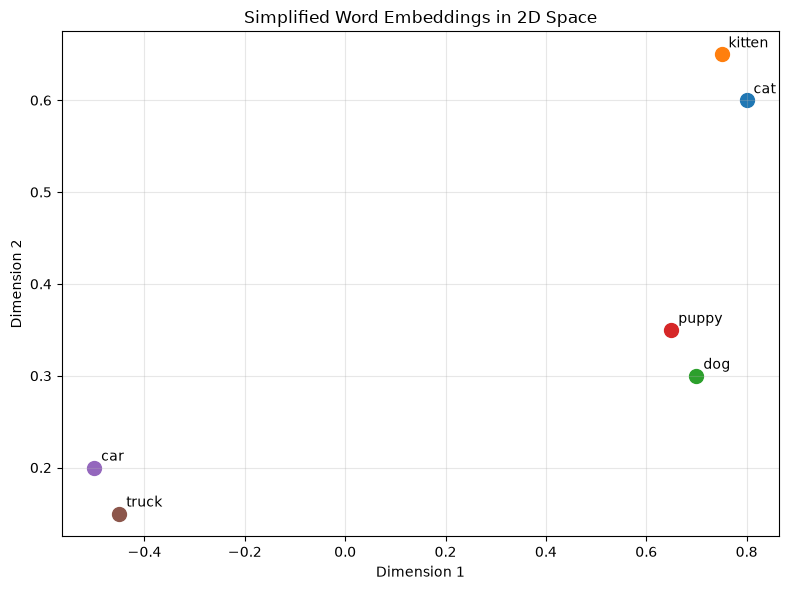

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5,5),
    textcoords='offset points')
    
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Measure similarity
import numpy as np
def cosin_similarity(Vec1,Vec2):
    """
    Cosin Similarity mesure the agle between two vectors.
    - Result close to 1 : Very Similar
    - Result close to 0: Not related
    - Results close to -1 : Opposite Meanings
    """ 
    dot_product=np.dot(Vec1,Vec2)
    norm_a=np.linalg.norm(Vec1)
    norm_b=np.linalg.norm(Vec2)
    result=dot_product/(norm_a*norm_b)
    return result

In [15]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitt_sim=cosin_similarity(kitten_vector,car_vector)
print(cat_kitt_sim)

-0.36432317655505975


## Open Source EmbeddingModels

In [16]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
os.environ("OPENAI_API_KEY")=os.getenv("OPENAI_API_KEY")
os.environ("")

In [17]:
# For hugging embediing no need of API KEY
from langchain_huggingface import HuggingFaceEmbeddings

embeddings=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
embeddings

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10849.97it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [18]:
# Create embedding with TEXT

text="This is a sentence-transformers model: It maps sentences & paragraphs to a 384 dimensional dense vector space and can be used for tasks like clustering or semantic search."
embeds=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embeddings Length : {len(embeds)}")
print(f"Embedding : {embeds}")

Text: This is a sentence-transformers model: It maps sentences & paragraphs to a 384 dimensional dense vector space and can be used for tasks like clustering or semantic search.
Embeddings Length : 384
Embedding : [0.009943380951881409, -0.03220859915018082, -0.024062057957053185, 0.04402179270982742, -0.004979204386472702, 0.09610773622989655, -0.0011138892732560635, -0.01495045330375433, 0.06346151977777481, -0.02885454148054123, 0.058401964604854584, 0.018612932413816452, 0.06741461157798767, 0.08543720841407776, -0.014104061760008335, 0.06504947692155838, 0.021965403109788895, 0.05082101747393608, -0.07815030962228775, -0.06837022304534912, 0.10219702124595642, 0.14314931631088257, 0.007845106534659863, 0.004672584123909473, -0.03654336929321289, 0.130954310297966, -0.016807712614536285, -0.10631117224693298, -0.01108974777162075, -0.019394230097532272, 0.013360980898141861, 0.041967764496803284, 0.018135689198970795, 0.1529507339000702, -0.026005985215306282, 0.04934508353471756, 

In [21]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
    ]
embedding_sentence=embeddings.embed_documents (sentences)
print(embedding_sentence[0])
print(embedding_sentence[1])


[0.1304018348455429, -0.011870198883116245, -0.02811698243021965, 0.05123862251639366, -0.055974479764699936, 0.030191566795110703, 0.030161341652274132, 0.02469833754003048, -0.01837052032351494, 0.05876683071255684, -0.024953164160251617, 0.060154207050800323, 0.03983161970973015, 0.03323054313659668, -0.061311379075050354, -0.04937309771776199, -0.05486350134015083, -0.04007606953382492, 0.056429147720336914, 0.039156582206487656, -0.03473707288503647, -0.013247726485133171, 0.0319662019610405, -0.06349916756153107, -0.06017855927348137, 0.07823450863361359, -0.028303882107138634, -0.04744279757142067, 0.04035935178399086, -0.0066309040412306786, -0.06674094498157501, -0.004191333428025246, -0.025311680510640144, 0.053341638296842575, 0.017428040504455566, -0.0979236289858818, 0.006061288062483072, -0.06524162739515305, 0.04557256028056145, 0.023641863837838173, 0.07658480852842331, -0.010264343582093716, -0.004076786804944277, -0.06232284754514694, 0.033705174922943115, 0.018661102

### OpenAI Embedding

In [7]:
import os
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings

load_dotenv()
os.environ["OPENAI_API_KEY"]==os.getenv("OPENAI_API_KEY")

embed=OpenAIEmbeddings(model="text-embedding-3-large")

In [9]:
#Single text embedding
single_text="Embedding models transform raw text—such as a sentence, paragraph, or tweet—into a fixed-length vector of numbers that captures its semantic meaning. "
single_embed=embed.embed_query(single_text)
print(f"Length of embedding : {len(single_embed)}")
print(f"Embedding are : {single_embed}")

Length of embedding : 3072
Embedding are : [0.01158905029296875, 0.02020263671875, -0.01045989990234375, -0.0316162109375, 0.0024433135986328125, -0.0173492431640625, 0.0030574798583984375, 0.00560760498046875, -0.0277252197265625, -0.0177154541015625, 0.027679443359375, -0.005828857421875, -0.0267486572265625, -0.0176544189453125, 0.015869140625, -0.007049560546875, -0.0022487640380859375, 0.02862548828125, 0.0205078125, -0.0158843994140625, -0.002696990966796875, -0.0010423660278320312, -0.0130615234375, -0.0195159912109375, 0.04705810546875, -0.0161590576171875, -0.016845703125, -0.0002655982971191406, -0.0232696533203125, 0.0531005859375, 0.0025081634521484375, -0.01187896728515625, -0.00965118408203125, -0.03802490234375, -0.03125, 0.0025272369384765625, 0.0268402099609375, 0.025726318359375, -0.03448486328125, -0.007038116455078125, 0.021453857421875, 0.006526947021484375, -0.04205322265625, 0.00537872314453125, -0.00908660888671875, -0.0079803466796875, -0.00634002685546875, -0.

### Cosin Similarity with OpenAI Embeddings

In [ ]:
# Example 1: Finding similar sentences

sentences = [
"The cat sat on the mat",
"A feline rested on the rug",
"The dog played in the yard",
"I love programming in Python",
"Python is my favorite programming language"
]

# Measure similarity
import numpy as np
def cosin_similarity(Vec1,Vec2):
    """
    Cosin Similarity mesure the agle between two vectors.
    - Result close to 1 : Very Similar
    - Result close to 0: Not related
    - Results close to -1 : Opposite Meanings
    """ 
    dot_product=np.dot(Vec1,Vec2)
    norm_a=np.linalg.norm(Vec1)
    norm_b=np.linalg.norm(Vec2)
    result=dot_product/(norm_a*norm_b)
    return result

## Convert into embedding
embed=OpenAIEmbeddings(model="text-embedding-3-large")
sentences_embed=embed.embed_documents(sentences)

## Calculate the simialrity betwween all pairs

for i in range(len(sentences)):
    for j in range(i+1,len(sentences)):
        similarity=cosin_similarity(sentences_embed[i],sentences_embed[j])
        print(f"'{sentences[i]}' vs '{sentences[j]}'")
        print (f"Similarity: {similarity:.3f}\n")

'The cat sat on the mat' vs 'A feline rested on the rug'
Similarity: 0.530

'The cat sat on the mat' vs 'The dog played in the yard'
Similarity: 0.334

'The cat sat on the mat' vs 'I love programming in Python'
Similarity: 0.110

'The cat sat on the mat' vs 'Python is my favorite programming language'
Similarity: 0.151

'A feline rested on the rug' vs 'The dog played in the yard'
Similarity: 0.336

'A feline rested on the rug' vs 'I love programming in Python'
Similarity: 0.066

'A feline rested on the rug' vs 'Python is my favorite programming language'
Similarity: 0.093

'The dog played in the yard' vs 'I love programming in Python'
Similarity: 0.143

'The dog played in the yard' vs 'Python is my favorite programming language'
Similarity: 0.131

'I love programming in Python' vs 'Python is my favorite programming language'
Similarity: 0.821



### Semantic search with OpenAI Embeddings

In [13]:
#Test semantic search

documents = [
    "LangChain is a framework for developing applications powered by language models",
    "Python is a high-level programming language",
    "Machine learning is a subset of artificial intelligence",
    "Embeddings convert text into numerical vectors",
    "The weather today is sunny and warm"
]
query="What is Langchain?"

embed=OpenAIEmbeddings(model="text-embedding-3-large")


def semantic_search(quary,documents,embeddings_model,top_k=3):
    """Simple Semantic Search Implementation"""

    quary_embed=embeddings_model.embed_query(quary)
    doc_embed=embeddings_model.embed_documents(documents)

    #Similarity Score

    similarities=[]

    for i,doc_embed in enumerate(doc_embed):
        similarity=cosin_similarity(quary_embed,doc_embed)
        similarities.append((similarity,documents[i]))

    similarities.sort(reverse=True)
    return similarities[:top_k]

results=semantic_search(query,documents,embed)

In [14]:
results

[(np.float64(0.6303544079983328),
  'LangChain is a framework for developing applications powered by language models'),
 (np.float64(0.1272845286022127),
  'Embeddings convert text into numerical vectors'),
 (np.float64(0.12024957439127447),
  'Machine learning is a subset of artificial intelligence')]

## Vectore Store and VectorDB 

In [29]:
import os
from dotenv import load_dotenv
load_dotenv()

# Libraries
from langchain_community.document_loaders.text import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_docling import DoclingLoader
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_community.document_loaders import DirectoryLoader,TextLoader
from langchain_chroma import Chroma

# Loader
loader=DirectoryLoader(
    "data/text_files",
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={'encoding':'utf-8'}
)
docs=loader.load()
print(f"{len(docs)}Documents are loaded ")

# Chunking
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    length_function=len,
    separators=["\n\n\n","\n\n",'\n'," ","",".",","]
)
chunks=text_splitter.split_documents(docs)
print(f"Length of the chunks are : {len(chunks)}")

# Embedding
embed=OpenAIEmbeddings(model="text-embedding-3-large")
print("Embedding mode intiated")

# Intialized Chroma DB Vector Store to store the chunks in vector representation
vector_store = Chroma(
    collection_name="example_VS",
    embedding_function=embed,
    persist_directory="./chroma_db", 
)
chroma_vs=vector_store.add_documents(documents=chunks)
print(f"Vector store created with {vector_store._collection.count()} vectors")



2Documents are loaded 
Length of the chunks are : 21
Embedding mode intiated
Vector store created with 21 vectors


In [36]:
# Test Similarity Search
query="What is the evolution of langchain"
similar_docs=vector_store.similarity_search(query,k=3)
for i in similar_docs:
    print(f"Metadata is : {i.metadata}")
    print(f"Similar documents : {i.page_content}\n\n ")

Metadata is : {'source': 'data/text_files/sample_2.txt'}
Similar documents : The Evolution of LangChain in AI Development
In the rapidly advancing field of artificial intelligence, developers are constantly seeking more efficient ways to build applications with large language models (LLMs). LangChain has emerged as a powerful framework that artificial intelligence developer use to create context-aware applications that leverage the capabilities of LLMs while addressing their limitations.
Press enter or click to view image in full size

 
Metadata is : {'source': 'data/text_files/sample_2.txt'}
Similar documents : Photo by Sergey Zolkin on Unsplash
What is LangChain?
LangChain is an open-source framework designed to simplify the development of applications powered by language models. Created to address the challenges of working with LLMs, it provides a standardized interface for chains of operations on language models.
Key Features of LangChain
Chains
The fundamental concept in LangChai

In [47]:
# Test Similarity Search
query="What is the evolution of langchain"
similar_docs=vector_store.similarity_search_with_score(query,k=3)
similar_docs

[(Document(id='6951d307-3531-4b07-ad89-cefb74cf17c7', metadata={'source': 'data/text_files/sample_2.txt'}, page_content='The Evolution of LangChain in AI Development\nIn the rapidly advancing field of artificial intelligence, developers are constantly seeking more efficient ways to build applications with large language models (LLMs). LangChain has emerged as a powerful framework that artificial intelligence developer use to create context-aware applications that leverage the capabilities of LLMs while addressing their limitations.\nPress enter or click to view image in full size'),
  0.5568218231201172),
 (Document(id='f59de0fe-710d-4990-a64c-9bbd0816a4af', metadata={'source': 'data/text_files/sample_2.txt'}, page_content='Photo by Sergey Zolkin on Unsplash\nWhat is LangChain?\nLangChain is an open-source framework designed to simplify the development of applications powered by language models. Created to address the challenges of working with LLMs, it provides a standardized interfac

### RAG using Langchain Expression Language

In [74]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import OllamaLLM
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

llm=OllamaLLM(model="llama3.1")

prompt=ChatPromptTemplate.from_template(
    """Use the following context to answer the question.
    If you don't know the answer based on the context, say you don't know.
    
    Provide specific details from the context to support your answer.
    Context:{context}
    Question: {question}
    Answer: """
    )
    
def rag_retriver(quary):
    ret=vector_store.as_retriever(search_kwargs={"k":3})
    similar_docs=ret._get_relevant_documents(query=quary,run_manager="Chroma")
    return "\n\n".join(doc.page_content for doc in similar_docs)
    
rag_chain_lcel=(
    {"context":rag_retriver,"question":RunnablePassthrough()}
    | prompt | llm | StrOutputParser()
)
rag_chain_lcel

{
  context: RunnableLambda(rag_retriver),
  question: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="Use the following context to answer the question.\n    If you don't know the answer based on the context, say you don't know.\n\n    Provide specific details from the context to support your answer.\n    Context:{context}\n    Question: {question}\n    Answer: "), additional_kwargs={})])
| OllamaLLM(model='llama3.1')
| StrOutputParser()

In [83]:
def rag_query_lcel(query):
    print(f"Question: {query}")
    print("-"* 50)

    res=rag_chain_lcel.invoke(query)
    print(f"Response : {res}")

    docs=vector_store.as_retriever(search_kwargs={"k":3})._get_relevant_documents(query=query,run_manager="Chroma")
    print("="*50)
    print(f"\n\nSource Documents are : \n")
    for i,doc in enumerate(docs):
        print(f"---Source {i+1}---")
        print(doc.page_content[:200]+"...")
        print("-"*50)

print("RAG - LCEL ")
rag_query_lcel(query="What are the key components of Langchain ?")
    

RAG - LCEL 
Question: What are the key components of Langchain ?
--------------------------------------------------
Response : According to the context, the key features of LangChain include:

* Chains: A fundamental concept in LangChain that represents a sequence of operations on language models.

Additionally, the text mentions "standardized components and patterns" as part of LangChain's design. However, it does not provide a detailed list of specific components beyond the "chains" feature.

Therefore, based on the context, one key component of LangChain is:

* Chains


Source Documents are : 

---Source 1---
Photo by Sergey Zolkin on Unsplash
What is LangChain?
LangChain is an open-source framework designed to simplify the development of applications powered by language models. Created to address the chal...
--------------------------------------------------
---Source 2---
LangChain represents an important step in the maturation of language model application development. By providi

In [79]:
query="What are the key components of Langchain ?"
docs=vector_store.as_retriever(search_kwargs={"k":3})._get_relevant_documents(query=query,run_manager="Chroma")
print(f"Source Documents are : \n")
for i,doc in enumerate(docs):
    print(f"---Source {i+1}---")
    print(doc.page_content[:200]+"...")

Source Documents are : 

---Source 1---
Photo by Sergey Zolkin on Unsplash
What is LangChain?
LangChain is an open-source framework designed to simplify the development of applications powered by language models. Created to address the chal...
---Source 2---
LangChain represents an important step in the maturation of language model application development. By providing standardized components and patterns, it enables artificial intelligence developers to ...
---Source 3---
The Evolution of LangChain in AI Development
In the rapidly advancing field of artificial intelligence, developers are constantly seeking more efficient ways to build applications with large language ...


### Adding new document to Vectore Store


In [ ]:
vector_store

In [86]:
new_doc="""
What are AI agents?
An AI agent is not just a piece of software—it’s a self-sustaining system capable of analyzing its environment, making decisions, working with tools and executing actions autonomously. These agents are built on advanced technologies like machine learning, natural language processing (NLP), and neural networks. They can navigate complex workflows, learn from user interactions, and operate in conversational and workflow-driven settings. Understanding the difference between agentic AI and AI agents helps clarify that agents are practical implementations of broader agentic AI principles.
AI agents in action: The tag team you didn't know you needed
In the world of AI agents, two distinct approaches are reshaping how businesses operate and interact with customers. Each offers unique capabilities that are profoundly transforming industries.
Conversational agents: The new voice of customer care
Imagine every customer interaction handled with the skill of your best support representative, available 24/7, without breaks. This is what conversational AI agents offer. They excel at text-based dialogues, grasping context, and providing responses that feel genuinely human.
These agents go beyond simple chatbots. They understand nuance, recognize emotions, and can even inject humor into conversations. They're at the forefront of the customer service revolution, tackling everything from basic inquiries to complex problem-solving with unprecedented efficiency.
Workflow agents: Automating the work you don’t want to do
While conversational agents take center stage, workflow agents are quietly revolutionizing business processes behind the scenes. They don't engage in conversation or aim to seem human. Their focus is singular: getting work done.
Workflow agents operate independently within business systems, making decisions, initiating actions, and automating tasks without human oversight. They streamline operations, allowing human workers to concentrate on tasks that demand creativity and emotional intelligence.
These two AI agents are improving existing processes and fundamentally changing what's possible in business automation. Let's explore how these agents are being used to reshape entire industries.
 """
new_doc

"\nWhat are AI agents?\nAn AI agent is not just a piece of software—it’s a self-sustaining system capable of analyzing its environment, making decisions, working with tools and executing actions autonomously. These agents are built on advanced technologies like machine learning, natural language processing (NLP), and neural networks. They can navigate complex workflows, learn from user interactions, and operate in conversational and workflow-driven settings. Understanding the difference between agentic AI and AI agents helps clarify that agents are practical implementations of broader agentic AI principles.\nAI agents in action: The tag team you didn't know you needed\nIn the world of AI agents, two distinct approaches are reshaping how businesses operate and interact with customers. Each offers unique capabilities that are profoundly transforming industries.\nConversational agents: The new voice of customer care\nImagine every customer interaction handled with the skill of your best s

In [87]:
vs_doc=Document(
    page_content=new_doc,
    metadata={"source":"Manually added","topic":"Agnetic AI"}
)
vs_doc

Document(metadata={'source': 'Manually added', 'topic': 'Agnetic AI'}, page_content="\nWhat are AI agents?\nAn AI agent is not just a piece of software—it’s a self-sustaining system capable of analyzing its environment, making decisions, working with tools and executing actions autonomously. These agents are built on advanced technologies like machine learning, natural language processing (NLP), and neural networks. They can navigate complex workflows, learn from user interactions, and operate in conversational and workflow-driven settings. Understanding the difference between agentic AI and AI agents helps clarify that agents are practical implementations of broader agentic AI principles.\nAI agents in action: The tag team you didn't know you needed\nIn the world of AI agents, two distinct approaches are reshaping how businesses operate and interact with customers. Each offers unique capabilities that are profoundly transforming industries.\nConversational agents: The new voice of cus